# Exploratory Data Analysis: KKBox Subscription Churn Dataset 


## 1. Data Preparation

The dataset contains millions of records describing user listening activity, subscription transactions, and demographic information.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.feature_selection import mutual_info_regression

### 1.1 Setup & data loading

In [2]:
train = pd.read_csv("train.csv")
transactions = pd.read_csv("transactions.csv")
user_logs = pd.read_csv("user_logs.csv")
members = pd.read_csv("members.csv")


In [3]:
print("Training Shape:", train.shape)
train.head()

Training Shape: (7377418, 6)


,msno,song_id,source_system_tab,source_screen_name,source_type,target
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,explore,Explore,online-playlist,1
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,my library,Local playlist more,local-playlist,1
2,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,my library,Local playlist more,local-playlist,1
3,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=,my library,Local playlist more,local-playlist,1
4,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=,explore,Explore,online-playlist,1


In [4]:
print("Transactions Shape:", transactions.shape)
transactions.head()

Transactions Shape: (1048575, 9)


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,YyO+tlZtAXYXoZhNr3Vg3+dfVQvrBVGO8j1mfqe4ZHc=,41,30,129,129,1,20150930,20151101,0
1,AZtu6Wl0gPojrEQYB8Q3vBSmE2wnZ3hi1FbK1rQQ0A4=,41,30,149,149,1,20150930,20151031,0
2,UkDFI97Qb6+s2LWcijVVv4rMAsORbVDT2wNXF0aVbns=,41,30,129,129,1,20150930,20160427,0
3,M1C56ijxozNaGD0t2h68PnH2xtx5iO5iR2MVYQB6nBI=,39,30,149,149,1,20150930,20151128,0
4,yvj6zyBUaqdbUQSrKsrZ+xNDVM62knauSZJzakS9OW4=,39,30,149,149,1,20150930,20151121,0


In [5]:

print("User Logs Shape:", user_logs.shape)
user_logs.head()

User Logs Shape: (1048575, 9)


,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
0,rxIP2f2aN0rYNp+toI0Obt/N/FYQX8hcO1fTmmy2h34=,20150513,0,0,0,0,1,1,280.335
1,rxIP2f2aN0rYNp+toI0Obt/N/FYQX8hcO1fTmmy2h34=,20150709,9,1,0,0,7,11,1658.948
2,yxiEWwE9VR5utpUecLxVdQ5B7NysUPfrNtGINaM2zA8=,20150105,3,3,0,0,68,36,17364.956
3,yxiEWwE9VR5utpUecLxVdQ5B7NysUPfrNtGINaM2zA8=,20150306,1,0,1,1,97,27,24667.317
4,yxiEWwE9VR5utpUecLxVdQ5B7NysUPfrNtGINaM2zA8=,20150501,3,0,0,0,38,38,9649.029


In [6]:
print("Members Shape:", members.shape)
members.head()

Members Shape: (34403, 7)


,msno,city,bd,gender,registered_via,registration_init_time,expiration_date
0,XQxgAYj3klVKjR3oxPPXYYFp4soD4TuBghkhMTD4oTw=,1,0,NaN,7,20110820,20170920
1,UizsfmJb9mV54qE9hCYyU07Va97c0lCRLEQX3ae+ztM=,1,0,NaN,7,20150628,20170622
2,D8nEhsIOBSoE6VthTaqDX8U6lqjJ7dLdr72mOyLya2A=,1,0,NaN,4,20160411,20170712
3,mCuD+tZ1hERA/o5GPqk38e041J8ZsBaLcu7nGoIIvhI=,1,0,NaN,9,20150906,20150907
4,q4HRBfVSssAFS9iRfxWrohxuk9kCYMKjHOEagUMV6rQ=,1,0,NaN,4,20170126,20170613


### 1.2. Dataset Structure and Quality Check

1.2.1 User Interaction Dataset

Several categorical variables describing how users accessed songs contained missing values that represent categories of user interaction. Missing values were replaced with an "Unknown" category to preserve observations while maintaining interpretability.


In [7]:
# Check for missing values in each dataset
train.isnull().sum()

msno                       0
song_id                    0
source_system_tab      24849
source_screen_name    414804
source_type            21539
target                     0
dtype: int64

In [8]:
#fill missing values
train['source_system_tab'] = train['source_system_tab'].fillna('Unknown')
train['source_screen_name'] = train['source_screen_name'].fillna('Unknown')
train['source_type'] = train['source_type'].fillna('Unknown')

In [9]:
#verify missing values are filled
train.isnull().sum()

msno                  0
song_id               0
source_system_tab     0
source_screen_name    0
source_type           0
target                0
dtype: int64

In [10]:
# Check for duplicate rows
train_duplicates = train.duplicated().sum()
print("Number of duplicate rows:", train_duplicates)

if train_duplicates > 0:
    display(train[train.duplicated()].head())

train = train.drop_duplicates()
print("Shape after dropping duplicates:", train.shape)

Number of duplicate rows: 0
Shape after dropping duplicates: (7377418, 6)


1.2.2 Transaction Dataset

The transaction dataset contained no missing values.

In [11]:
# Check for missing values in each dataset
transactions.isnull().sum()

msno                      0
payment_method_id         0
payment_plan_days         0
plan_list_price           0
actual_amount_paid        0
is_auto_renew             0
transaction_date          0
membership_expire_date    0
is_cancel                 0
dtype: int64

In [12]:
# Check for duplicate rows
transactions_duplicates = transactions.duplicated().sum()
print("Number of duplicate rows:", transactions_duplicates)

if transactions_duplicates > 0:
    display(transactions[transactions.duplicated()].head())

transactions = transactions.drop_duplicates()
print("Shape after dropping duplicates:", transactions.shape)

Number of duplicate rows: 6


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
268125,YRz/wpzedhcmTNeJ+B485UMRdD1fcABdSCNEViU6rbs=,41,30,99,99,1,20151123,20151223,0
433964,VOxnOPzzle50wpnquLZPMzK1jnnalxBv5QFY1QjHbKg=,41,30,99,99,1,20160607,20160706,0
830500,HmEvZwwb4yzb5Kzbd7SKuOFfrDbcA94Ow9EVEvBnYGY=,41,30,99,99,1,20161215,20170114,0
848601,QXbDC7myHf7YqERLEATSKSU/Wop/jHYRPoynT5F/erw=,41,30,99,99,1,20160818,20160917,0
936049,BAZcbyou9d9vLiUmhwRWqM0z/N0sj3OhADFiiWfba2M=,41,30,99,99,1,20161225,20170124,0


Shape after dropping duplicates: (1048569, 9)


1.2.3 User Log Dataset

The user log dataset contained no missing values.

In [13]:
# Check for missing values in each dataset
user_logs.isnull().sum()

msno          0
date          0
num_25        0
num_50        0
num_75        0
num_985       0
num_100       0
num_unq       0
total_secs    0
dtype: int64

In [14]:
# Check for duplicate rows
user_logs_duplicates = user_logs.duplicated().sum()
print("Number of duplicate rows:", user_logs_duplicates)

if user_logs_duplicates > 0:
    display(user_logs[user_logs.duplicated()].head())

user_logs = user_logs.drop_duplicates()
print("Shape after dropping duplicates:", user_logs.shape)

Number of duplicate rows: 0
Shape after dropping duplicates: (1048575, 9)


1.2.4 Memeber Dataset


Gender was the only column missing values and was replaced with an "Unknown" category to preserve observations while maintaining interpretability.

In [15]:
# Check for missing values in each dataset
members.isnull().sum()

msno                          0
city                          0
bd                            0
gender                    19902
registered_via                0
registration_init_time        0
expiration_date               0
dtype: int64

In [16]:
#fill missing values in members dataset
members['gender'] = members['gender'].fillna("Unknown")

In [17]:
#verify missing values are filled
members.isnull().sum()

msno                      0
city                      0
bd                        0
gender                    0
registered_via            0
registration_init_time    0
expiration_date           0
dtype: int64

In [18]:
# Check for duplicate rows
members_duplicates = members.duplicated().sum()
print("Number of duplicate rows:", members_duplicates)

if members_duplicates > 0:
    display(members[members.duplicated()].head())

members = members.drop_duplicates()
print("Shape after dropping duplicates:", members.shape)

Number of duplicate rows: 0
Shape after dropping duplicates: (34403, 7)


### 1.3 Data dictionary

#### User Interaction Dataset

| Variable               | Meaning                                                                                                                     |
| ---------------------- | --------------------------------------------------------------------------------------------------------------------------- |
| **msno**               | Unique user identifier used across all datasets.                                                                            |
| **song_id**            | Unique identifier for the song that was played.                                                                             |
| **source_system_tab**  | The main tab in the application where the user accessed the song (e.g., discover, search, radio).                           |
| **source_screen_name** | The specific screen or interface page where the song playback was initiated.                                                |
| **source_type**        | The type of content source that generated the playback (such as playlist, album, search result, or recommendation).         |
| **target**             | Indicator of whether the user interacted positively with the song (typically whether the song was listened to or selected). |


#### Transaction Dataset

| Variable                   | Meaning                                                                         |
| -------------------------- | ------------------------------------------------------------------------------- |
| **msno**                   | Unique user identifier linking subscription activity to a specific user.        |
| **payment_method_id**      | Identifier representing the payment method used by the user.                    |
| **payment_plan_days**      | Number of days included in the subscription plan purchased by the user.         |
| **plan_list_price**        | The standard listed price of the subscription plan in New Taiwan Dollars (NTD). |
| **actual_amount_paid**     | The actual amount the user paid after discounts or promotions.                  |
| **is_auto_renew**          | Indicates whether the user enabled automatic subscription renewal.              |
| **transaction_date**       | The date on which the subscription transaction occurred.                        |
| **membership_expire_date** | The date when the user's subscription membership is scheduled to expire.        |
| **is_cancel**              | Indicates whether the user canceled their subscription in that transaction.     |


#### User Listening Logs Dataset

| Variable       | Meaning                                                                                      |
| -------------- | -------------------------------------------------------------------------------------------- |
| **msno**       | Unique user identifier.                                                                      |
| **date**       | Date when the listening activity occurred.                                                   |
| **num_25**     | Number of songs played for less than 25% of their total length.                              |
| **num_50**     | Number of songs played between 25% and 50% of their total length.                            |
| **num_75**     | Number of songs played between 50% and 75% of their total length.                            |
| **num_985**    | Number of songs played between 75% and 98.5% of their total length.                          |
| **num_100**    | Number of songs played for more than 98.5% of their total length (essentially fully played). |
| **num_unq**    | Number of unique songs played by the user.                                                   |
| **total_secs** | Total number of seconds the user spent listening to music.                                   |


Member Dataset

| Variable                                      | Meaning                                                                                                                                                                |
| --------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **msno**                                      | Unique user identifier used to link user information across all datasets.                                                                                              |
| **city**                                      | The city where the user registered for the service.                                                                                                                    |
| **bd**                                        | User age (birthdate-derived). This field contains extreme outliers and unrealistic values that require cleaning.                                                       |
| **gender**                                    | Gender of the user (e.g., male or female). Some records may contain missing values.                                                                                    |
| **registered_via**                            | The method used by the user to register for the service (such as mobile app, website, or third-party login).                                                           |
| **registration_init_time**                    | The date when the user initially registered for the service.                                                                                                           |
| **expiration_date** *(only in older version)* | A snapshot of the user's membership expiration date at the time the dataset was extracted. This field does not necessarily represent the user's actual churn behavior. |


### 1.4 .Data Cleaning and Standardization

1.4.1 User Interaction Dataset

Standardized column names by removing extra spaces and converting them to lowercase for consistency.

In [31]:
# standardize column names
train.columns = train.columns.str.strip().str.lower()
print("Standardized column names:", train.columns)

print(train.describe())

Standardized column names: Index(['msno', 'song_id', 'source_system_tab', 'source_screen_name',
       'source_type', 'target'],
      dtype='object')
             target
count  7.377418e+06
mean   5.035171e-01
std    4.999877e-01
min    0.000000e+00
25%    0.000000e+00
50%    1.000000e+00
75%    1.000000e+00
max    1.000000e+00


1.4.2 Transaction Dataset

Standardized by converting date variables into datetime format, Creating a new feature called subscription_length, to measure the length of each subscription period. Invalid negative values were replaced with NaN to improve data quality.

In [30]:
# standardize column names
transactions.columns = transactions.columns.str.strip().str.lower()

# convert date columns
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date'], format='%Y%m%d', errors='coerce'
)
transactions['membership_expire_date'] = pd.to_datetime(
    transactions['membership_expire_date'], format='%Y%m%d', errors='coerce'
)

# create useful feature
transactions['subscription_length'] = (
    transactions['membership_expire_date'] - transactions['transaction_date']
).dt.days

# remove impossible values
transactions.loc[transactions['payment_plan_days'] < 0, 'payment_plan_days'] = np.nan
transactions.loc[transactions['plan_list_price'] < 0, 'plan_list_price'] = np.nan
transactions.loc[transactions['actual_amount_paid'] < 0, 'actual_amount_paid'] = np.nan
transactions.loc[transactions['subscription_length'] < 0, 'subscription_length'] = np.nan


print(transactions.describe())

       payment_method_id  payment_plan_days  plan_list_price  \
count       1.048569e+06       1.048569e+06     1.048569e+06   
mean        3.893354e+01       3.130154e+01     1.397350e+02   
min         2.000000e+00       0.000000e+00     0.000000e+00   
25%         3.800000e+01       3.000000e+01     9.900000e+01   
50%         4.100000e+01       3.000000e+01     1.490000e+02   
75%         4.100000e+01       3.000000e+01     1.490000e+02   
max         4.100000e+01       4.500000e+02     2.000000e+03   
std         3.502966e+00       3.020871e+01     1.302818e+02   

       actual_amount_paid  is_auto_renew               transaction_date  \
count        1.048569e+06   1.048569e+06                        1048569   
mean         1.418584e+02   8.519601e-01  2016-03-09 17:48:32.326800896   
min          0.000000e+00   0.000000e+00            2015-01-01 00:00:00   
25%          9.900000e+01   1.000000e+00            2015-09-07 00:00:00   
50%          1.490000e+02   1.000000e+00        

1.4.3 User Log Dataset

Standardized column names by removing extra spaces and converting them to lowercase for consistency. Converting the activity date into datetime format. Invalid negative values were replaced with NaN to improve data quality. Additional behavioral features such as total_plays and completion_rate were created to better represent user engagement with the platform.

In [29]:
# standardize column names
user_logs.columns = user_logs.columns.str.strip().str.lower()

# convert date column
user_logs['date'] = pd.to_datetime(
    user_logs['date'], format='%Y%m%d', errors='coerce'
)

# replace negative values with NaN
log_cols = ['num_25', 'num_50', 'num_75', 'num_985', 'num_100', 'num_unq', 'total_secs']
for col in log_cols:
    user_logs.loc[user_logs[col] < 0, col] = np.nan

# create total plays
user_logs['total_plays'] = (
    user_logs['num_25'] +
    user_logs['num_50'] +
    user_logs['num_75'] +
    user_logs['num_985'] +
    user_logs['num_100']
)

# create completion rate
user_logs['completion_rate'] = np.where(
    user_logs['total_plays'] > 0,
    user_logs['num_100'] / user_logs['total_plays'],
    0
)

print(user_logs.describe())

                                date        num_25        num_50  \
count                        1048575  1.048575e+06  1.048575e+06   
mean   2016-02-24 10:27:08.484371712  6.521748e+00  1.646989e+00   
min              2015-01-01 00:00:00  0.000000e+00  0.000000e+00   
25%              2015-08-17 00:00:00  0.000000e+00  0.000000e+00   
50%              2016-03-10 00:00:00  2.000000e+00  1.000000e+00   
75%              2016-09-10 00:00:00  7.000000e+00  2.000000e+00   
max              2017-02-28 00:00:00  1.377000e+03  4.940000e+02   
std                              NaN  1.395287e+01  4.260586e+00   

             num_75       num_985       num_100       num_unq    total_secs  \
count  1.048575e+06  1.048575e+06  1.048575e+06  1.048575e+06  1.048396e+06   
mean   1.019367e+00  1.130623e+00  3.068215e+01  3.010017e+01  8.172334e+03   
min    0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00  2.000000e-03   
25%    0.000000e+00  0.000000e+00  6.000000e+00  8.000000e+00  1.891708

1.4.4 Member Dataset

Standardized column names by removing extra spaces and converting them to lowercase for consistency. Formatting date variables and cleaning the age variable to remove unrealistic outliers. These steps improved the reliability of demographic features used in the analysis.

In [28]:
# standardize column names
members.columns = members.columns.str.strip().str.lower()

# convert registration date
members['registration_init_time'] = pd.to_datetime(
    members['registration_init_time'], format='%Y%m%d', errors='coerce'
)

# convert expiration_date if it exists
if 'expiration_date' in members.columns:
    members['expiration_date'] = pd.to_datetime(
        members['expiration_date'], format='%Y%m%d', errors='coerce'
    )

# clean age column
members['bd'] = members['bd'].replace(0, np.nan)
members.loc[(members['bd'] < 10) | (members['bd'] > 100), 'bd'] = np.nan


print(members.describe())

               city            bd  registered_via  \
count  34403.000000  14442.000000    34403.000000   
mean       5.371276     28.905830        5.953376   
min        1.000000     10.000000        3.000000   
25%        1.000000     22.000000        4.000000   
50%        1.000000     27.000000        7.000000   
75%       10.000000     34.000000        9.000000   
max       22.000000     97.000000       16.000000   
std        6.243929      9.162136        2.287534   

              registration_init_time                expiration_date  
count                          34403                          34403  
mean   2014-06-07 19:28:51.093218560  2017-06-03 10:39:36.839229184  
min              2004-03-26 00:00:00            1970-01-01 00:00:00  
25%              2012-10-27 00:00:00            2017-02-01 00:00:00  
50%              2015-09-05 00:00:00            2017-09-09 00:00:00  
75%              2016-11-02 00:00:00            2017-09-30 00:00:00  
max              2017-02-28 00:0

## 2. Feature Engineering

Feature engineering was performed to create behavioral and engagement features that summarize user activity. Transaction records were aggregated to generate subscription-related metrics such as average payment amount, auto-renew rate, and cancellation frequency. Listening logs were summarized to capture engagement metrics including total plays, completion rate, and average listening time. 

### 2.1 Transaction-Based Features

In [23]:
transactions['subscription_length'] = (
    transactions['membership_expire_date'] - transactions['transaction_date']
).dt.days

transactions_agg = transactions.groupby('msno').agg({
    'payment_plan_days':'mean',
    'actual_amount_paid':'mean',
    'is_auto_renew':'mean',
    'is_cancel':'sum',
    'subscription_length':'mean'
}).reset_index()

transactions_agg.columns = [
    'msno',
    'avg_plan_days',
    'avg_amount_paid',
    'auto_renew_rate',
    'total_cancels',
    'avg_subscription_length'
]

print(transactions_agg.head())

                                           msno  avg_plan_days  \
0  +++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=           30.0   
1  +++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=           30.0   
2  ++/9R3sX37CjxbY/AaGvbwr3QkwElKBCtSvVzhCBDOk=           30.0   
3  ++/ZHqwUNa7U21Qz+zqteiXlZapxey86l6eEorrak/g=           15.0   
4  ++/imsKMXignukHBIRfOhocobbR8Qk1Ew5mhjOCJg5A=            7.0   

   avg_amount_paid  auto_renew_rate  total_cancels  avg_subscription_length  
0             99.0              1.0              0                     31.0  
1            149.0              1.0              0                     31.0  
2            149.0              1.0              0                     31.0  
3            149.0              1.0              0                     33.0  
4              0.0              0.0              0                      1.0  


| Feature                 | Meaning                                                        |
| ----------------------- | -------------------------------------------------------------- |
| avg_plan_days           | Average number of days in the user’s subscription plan         |
| avg_amount_paid         | Average payment amount per transaction                         |
| auto_renew_rate         | Percentage of transactions where auto-renew was enabled        |
| total_cancels           | Total number of times a user canceled a subscription           |
| avg_subscription_length | Average number of days between transaction date and expiration |


### 2.2 User Engagement Features

In [24]:
logs_agg = user_logs.groupby('msno').agg({
    'total_plays':'sum',
    'completion_rate':'mean',
    'num_unq':'mean',
    'total_secs':'mean'
}).reset_index()

logs_agg.columns = [
    'msno',
    'total_plays',
    'avg_completion_rate',
    'avg_unique_songs',
    'avg_listening_time'
]
print(logs_agg.head())

                                           msno  total_plays  \
0  +++FOrTS7ab3tIgIh8eWwX4FqRv8w/FoiOuyXsFvphY=         13.0   
1  +++dz9ZCWE2HB/47pJU82NJXQzQuZDx1Wm50YSk/kKk=         69.0   
2  ++5IYGT7+CWMJ8hRsqoQLoaTXBLMJzlfK12eMTr9Ilw=          2.0   
3  ++7jYuHyUSp41PyuttFx/MCepv7TdFQULgN8TxZULZk=         33.0   
4  ++95tJZADNg8U8HKbYdxbbXIRsO6pw1zBK4tHI7BtZo=        349.0   

   avg_completion_rate  avg_unique_songs  avg_listening_time  
0             0.769231             10.00         2998.267000  
1             0.942029             54.00        17132.904000  
2             1.000000              2.00          448.574000  
3             0.673882             10.00         1594.556000  
4             0.805855             14.75         6674.200167  


| Feature            | Meaning                                           |
| ------------------ | ------------------------------------------------- |
| total_plays        | Total number of songs played                      |
| completion_rate    | Percentage of songs listened to almost completely |
| avg_unique_songs   | Average number of unique songs played             |
| avg_listening_time | Average listening time in seconds                 |


## 3. Data Integration

The datasets was integrated using msno, which uniquely identifies each user. The completed dataset was then saved as kkbox_dataset.csv for further analysis and modeling.

### 3.1 The merge

The churn label dataset was first merged with the aggregated transaction features, followed by the aggregated user log features and the cleaned member information. A left join was used so that all users in the churn dataset were retained in the final integrated table.

In [25]:
# merge churn labels with aggregated transaction features
kkbox_dataset = train.merge(transactions_agg, on='msno', how='left')

# merge aggregated listening behavior features
kkbox_dataset = kkbox_dataset.merge(logs_agg, on='msno', how='left')

# merge member demographic information
kkbox_dataset = kkbox_dataset.merge(members, on='msno', how='left')

In [26]:
print("Final dataset shape:", kkbox_dataset.shape)
print(kkbox_dataset.head())

kkbox_dataset.to_csv("kkbox_dataset.csv", index=False)

Final dataset shape: (7377418, 21)
                                           msno  \
0  FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=   
1  Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=   
2  Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=   
3  Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=   
4  FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=   

                                        song_id source_system_tab  \
0  BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=           explore   
1  bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=        my library   
2  JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=        my library   
3  2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=        my library   
4  3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=           explore   

    source_screen_name      source_type  target  avg_plan_days  \
0              Explore  online-playlist       1           30.0   
1  Local playlist more   local-playlist       1            NaN   
2  Local playlist more   local-playlist      

## 4. Feature Analysis

In [6]:
df = pd.read_csv("kkbox_dataset.csv")

### 4.1 Churn Distribution Analysis

Text(0.5, 1.0, 'Distribution of Churn')

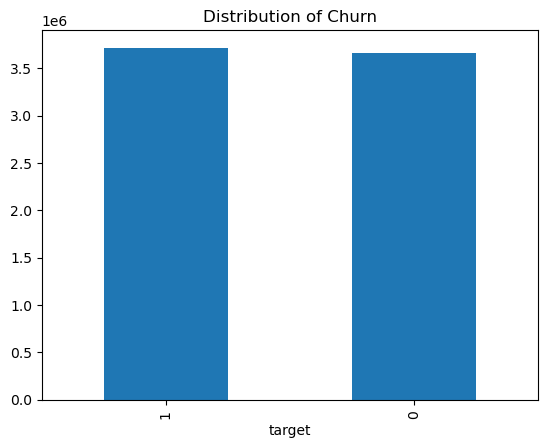

In [33]:
df['target'].value_counts().plot(kind='bar')
plt.title('Distribution of Churn')

The distribution of the target variable shows that the dataset contains nearly equal numbers of churned and non-churned users. This indicates that the dataset is relatively balanced. Balanced class distributions are beneficial for predictive modeling because they reduce the risk of model bias toward one class and allow machine learning algorithms to learn patterns from both churn and non-churn cases.

### 4.2 Auto-Renew Behavior vs Churn

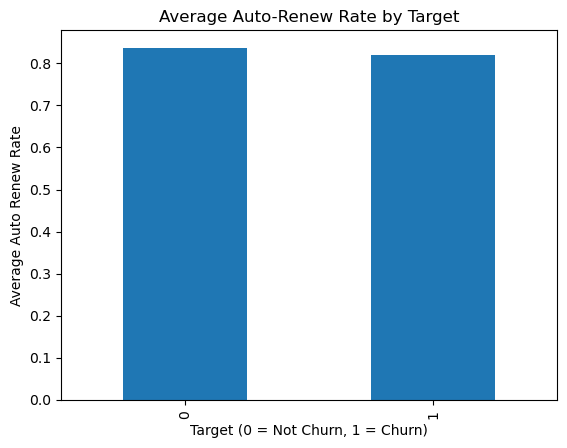

In [7]:
auto_renew = df.groupby('target')['auto_renew_rate'].mean()

auto_renew.plot(kind='bar')
plt.title("Average Auto-Renew Rate by Target")
plt.xlabel("Target (0 = Not Churn, 1 = Churn)")
plt.ylabel("Average Auto Renew Rate")
plt.show()

In [8]:
pd.crosstab(df['target'], 
            df['auto_renew_rate'] > 0, 
            normalize='index')

auto_renew_rate,False,True
target,,
0,0.641919,0.358081
1,0.636845,0.363155


The analysis of auto-renew behavior shows that the proportion of users who enable auto-renew is very similar for both churned and non-churned groups. Approximately 64% of users do not use auto-renew, while about 36% do, and these percentages remain nearly identical regardless of churn status. This indicates that auto-renew usage alone does not strongly differentiate between users who churn and those who remain subscribed. While the feature may still contribute useful information in combination with other behavioral variables, it does not appear to be a strong standalone predictor of churn in this dataset.

### 4.3 Listening Engagement vs Churn

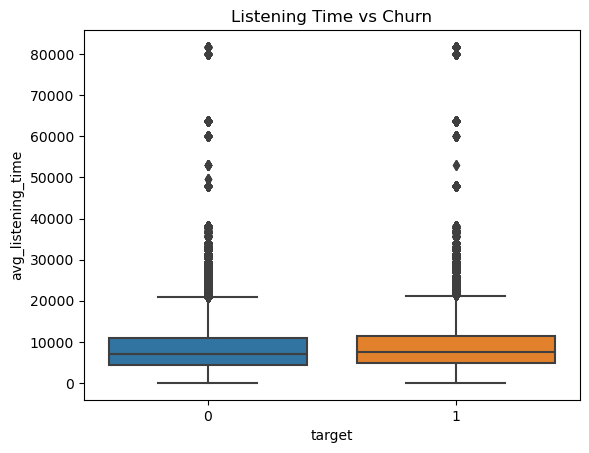

In [11]:
df.groupby('target')['avg_listening_time'].mean()

sns.boxplot(x='target', y='avg_listening_time', data=df)
plt.title("Listening Time vs Churn")
plt.show()

The boxplot compares the average listening time between users who churned  and those who did not churn . Both groups show a wide distribution of listening time, with many outliers representing users who listen to significantly more music than average. The median listening time for churned users appears slightly higher than for non-churned users, suggesting that listening time alone may not strongly distinguish between the two groups. Overall, this indicates that while listening activity varies widely among users, average listening time by itself may not be a strong standalone predictor of churn and should be considered alongside other behavioral features.

### 4.4 Cancellation Behavior

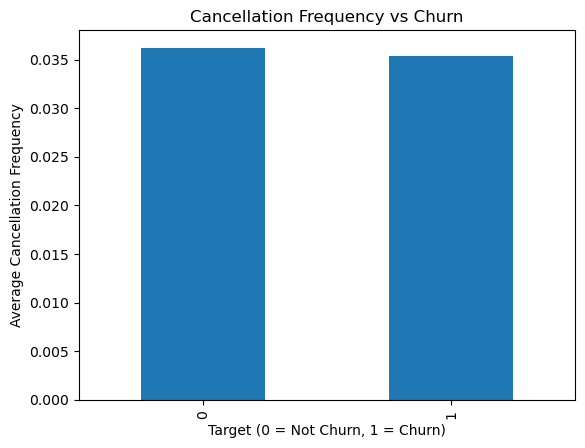

In [14]:
cancel = df.groupby('target')['total_cancels'].mean()

cancel.plot(kind='bar')
plt.title("Cancellation Frequency vs Churn")
plt.xlabel("Target (0 = Not Churn, 1 = Churn)")
plt.ylabel("Average Cancellation Frequency")
plt.show()



The bar chart compares the average cancellation frequency between users who churned and those who did not churn . The results show that the average cancellation frequency is very similar for both groups, with only a slight difference between churned and non-churned users. This suggests that cancellation frequency alone does not strongly distinguish between users who churn and those who remain subscribed. Therefore, while cancellation behavior may still contribute useful information, it is likely more informative when analyzed alongside other behavioral features.

### 4.5 Song Completion Rate

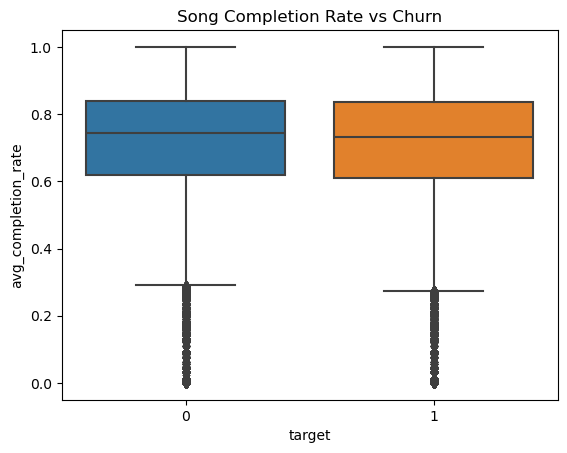

In [15]:
df.groupby('target')['avg_completion_rate'].mean()

sns.boxplot(x='target', y='avg_completion_rate', data=df)
plt.title("Song Completion Rate vs Churn")
plt.show()

The boxplot compares the average song completion rate between users who churned (target = 1) and those who did not churn (target = 0). Both groups show very similar distributions, with median completion rates around 0.7–0.75 and overlapping interquartile ranges. This indicates that users generally listen to a large portion of songs regardless of their churn status. Overall, the similarity between the two groups suggests that song completion rate alone may not strongly differentiate churn behavior and is likely more useful when combined with other engagement features.

### 4.6 Correlation Analysis

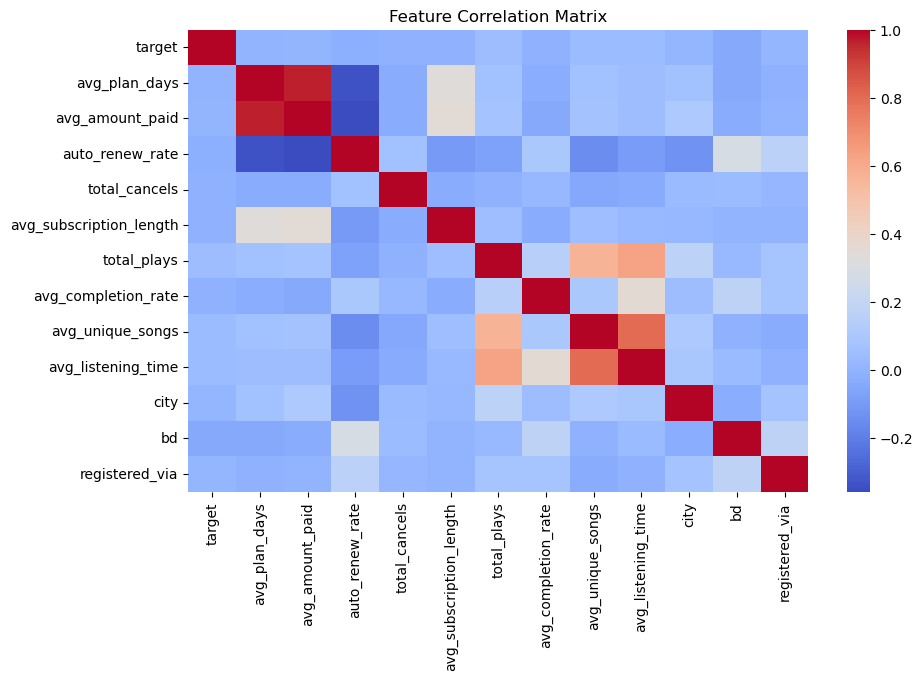

In [16]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

The correlation matrix illustrates the relationships between the engineered features and the target variable. Most features show weak correlations with the target, suggesting that no single variable strongly explains churn on its own. However, some behavioral features such as total plays, average listening time, and average unique songs show stronger correlations with each other, indicating that they all capture aspects of user engagement with the platform. Overall, the results suggest that churn is likely influenced by a combination of multiple behavioral and subscription-related factors rather than a single dominant feature.

### 4.7 Key Findings from the Exploratory Data Analysis

The exploratory data analysis revealed that no single feature strongly differentiates churned users from retained users. Behavioral variables such as listening time, song completion rate, and cancellation frequency show similar distributions across both groups. The correlation analysis further indicates that churn is weakly correlated with individual features but engagement-related variables are strongly correlated with each other. These findings suggest that churn prediction will likely require combining multiple behavioral and subscription features within a machine learning model rather than relying on a single dominant predictor.